# 03C: DBSCAN Stock Clustering

## Objective
Use density-based clustering (DBSCAN) on shared cached features and analyze noise/outliers.

In [12]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn kagglehub

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import kagglehub

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

Note: you may need to restart the kernel to use updated packages.


In [13]:
cwd = Path.cwd()
TASK_FOLDER = '03_stock_clustering_analysis'
if cwd.name == 'implementation':
    task_root = cwd.parent
elif cwd.name == TASK_FOLDER:
    task_root = cwd
elif (cwd / TASK_FOLDER).exists():
    task_root = cwd / TASK_FOLDER
else:
    task_root = cwd
DATA_DIR = task_root / 'data'
GRAPH_DIR = task_root / 'graph'
DATA_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
RAW_CACHE = DATA_DIR / 'sp500_raw.csv'
FEATURE_CACHE = DATA_DIR / 'clustering_features_latest.csv'

In [14]:
def create_clustering_features(stock_data: pd.DataFrame) -> pd.DataFrame:
    stock_data = stock_data.sort_values('date').reset_index(drop=True).copy()
    stock_data['volatility'] = stock_data['close'].pct_change().rolling(20).std()
    stock_data['avg_return'] = stock_data['close'].pct_change().rolling(20).mean()
    stock_data['avg_volume'] = stock_data['volume'].rolling(20).mean()
    stock_data['volume_volatility'] = stock_data['volume'].rolling(20).std() / stock_data['volume'].rolling(20).mean()
    stock_data['momentum'] = (stock_data['close'] - stock_data['close'].shift(20)) / stock_data['close'].shift(20)
    stock_data['price_range'] = (stock_data['high'] - stock_data['low']) / stock_data['close']
    stock_data['trend_strength'] = (stock_data['close'] - stock_data['low']) / (stock_data['high'] - stock_data['low'])
    stock_data['price_level'] = stock_data['close'] / 100
    stock_data['volume_to_price_ratio'] = stock_data['volume'] / stock_data['close']
    return stock_data

def load_raw_data() -> pd.DataFrame:
    if RAW_CACHE.exists():
        return pd.read_csv(RAW_CACHE)
    path = kagglehub.dataset_download('camnugent/sandp500')
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    df.to_csv(RAW_CACHE, index=False)
    return df

def load_feature_table(data: pd.DataFrame) -> pd.DataFrame:
    if FEATURE_CACHE.exists():
        return pd.read_csv(FEATURE_CACHE)
    processed = pd.concat([create_clustering_features(data[data['Name'] == s]) for s in data['Name'].unique()], ignore_index=True)
    clustering_data = processed.sort_values('date').drop_duplicates('Name', keep='last').dropna().reset_index(drop=True)
    clustering_data.to_csv(FEATURE_CACHE, index=False)
    return clustering_data

data = load_raw_data()
clustering_data = load_feature_table(data)
feature_cols = ['volatility','avg_return','avg_volume','volume_volatility','momentum','price_range','trend_strength','price_level','volume_to_price_ratio']
X = clustering_data[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(clustering_data[feature_cols].median(numeric_only=True))

# Reduce extreme-value dominance for distance-based density clustering.
for col in feature_cols:
    lower, upper = X[col].quantile([0.01, 0.99])
    X[col] = X[col].clip(lower=lower, upper=upper)

X_scaled = StandardScaler().fit_transform(X)

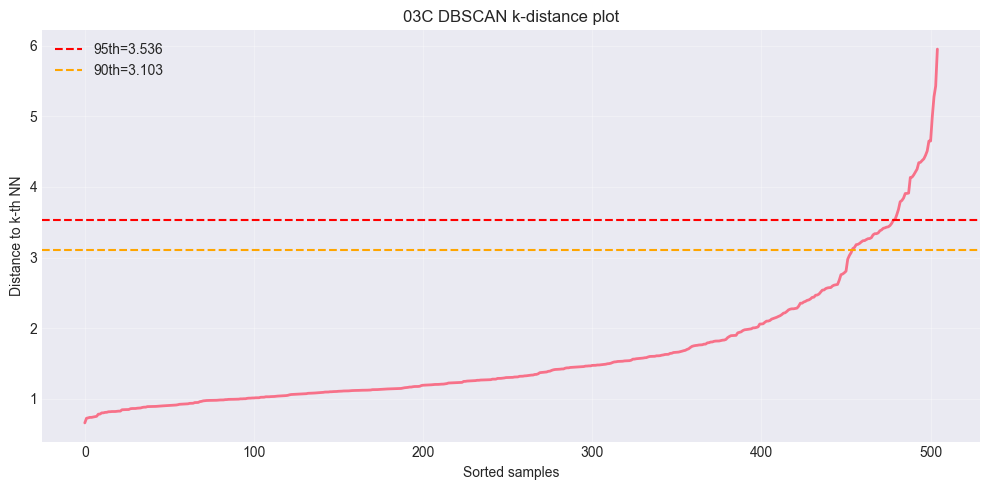

Using eps=3.536, min_samples=8


In [ ]:
# k-distance heuristic for eps candidate range (final eps is chosen by auto-search)
min_samples = 8
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
kdist = np.sort(distances[:, -1])

eps_90 = float(np.percentile(kdist, 90))
eps_95 = float(np.percentile(kdist, 95))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(kdist, linewidth=2)
ax.axhline(eps_95, color='red', linestyle='--', label=f'95th={eps_95:.3f}')
ax.axhline(eps_90, color='orange', linestyle='--', label=f'90th={eps_90:.3f}')
ax.set_title('03C DBSCAN k-distance plot')
ax.set_xlabel('Sorted samples'); ax.set_ylabel('Distance to k-th NN')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(GRAPH_DIR / '03C_01_kdistance.png', dpi=300, bbox_inches='tight'); plt.show()

print(f'[INFO] eps candidate range from k-distance: {eps_90:.3f} to {eps_95:.3f}')
print('[INFO] Final eps/min_samples will be selected by the auto-search cell below.')

In [16]:
# Auto-search DBSCAN parameters to avoid degenerate one-cluster solutions
n_samples = X_scaled.shape[0]
min_samples_grid = [5, 8, 10, 12]
eps_grid = np.percentile(kdist, np.arange(75, 96, 2))

candidates = []
for ms in min_samples_grid:
    for eps_candidate in eps_grid:
        model = DBSCAN(eps=float(eps_candidate), min_samples=ms)
        labels_tmp = model.fit_predict(X_scaled)

        n_clusters_tmp = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
        noise_ratio_tmp = float((labels_tmp == -1).mean())

        # Skip clearly unusable partitions.
        if n_clusters_tmp < 2:
            continue

        valid_mask_tmp = labels_tmp != -1
        if valid_mask_tmp.sum() <= n_clusters_tmp:
            continue

        sil_tmp = silhouette_score(X_scaled[valid_mask_tmp], labels_tmp[valid_mask_tmp])
        dbi_tmp = davies_bouldin_score(X_scaled[valid_mask_tmp], labels_tmp[valid_mask_tmp])

        # Prefer strong separation, compact clusters, and moderate noise.
        score_tmp = sil_tmp - 0.15 * dbi_tmp - 0.10 * abs(noise_ratio_tmp - 0.15)

        candidates.append({
            'eps': float(eps_candidate),
            'min_samples': ms,
            'n_clusters': n_clusters_tmp,
            'noise_ratio': noise_ratio_tmp,
            'silhouette': sil_tmp,
            'dbi': dbi_tmp,
            'score': score_tmp
        })

if not candidates:
    print('[WARN] Auto-search found no valid >=2-cluster solution; fallback to percentile heuristic.')
    min_samples = 8
    eps = float(np.percentile(kdist, 90))
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
else:
    candidates_df = pd.DataFrame(candidates).sort_values('score', ascending=False)
    display(candidates_df.head(10))

    best = candidates_df.iloc[0]
    eps = float(best['eps'])
    min_samples = int(best['min_samples'])

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

clustering_data['cluster'] = labels

noise_ratio = float((labels == -1).mean())
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f'Chosen eps={eps:.3f}, min_samples={min_samples}')
print(f'Clusters found={n_clusters}, noise_ratio={noise_ratio:.2%}')

valid_mask = labels != -1
if valid_mask.sum() > 2 and len(np.unique(labels[valid_mask])) > 1:
    sil = silhouette_score(X_scaled[valid_mask], labels[valid_mask])
    dbi = davies_bouldin_score(X_scaled[valid_mask], labels[valid_mask])
    print(f'Silhouette (non-noise)={sil:.4f}, Davies-Bouldin (non-noise)={dbi:.4f}')
else:
    print('Not enough non-noise clusters for silhouette/DBI.')

cluster_summary = clustering_data[clustering_data['cluster'] != -1].groupby('cluster')[feature_cols].mean().round(4)
display(cluster_summary)

cluster_summary.to_csv(DATA_DIR / '03C_cluster_feature_summary.csv')
clustering_data[['Name', 'cluster'] + feature_cols].to_csv(DATA_DIR / '03C_stock_cluster_assignments.csv', index=False)

,eps,min_samples,n_clusters,noise_ratio,silhouette,dbi,score
0,2.273898,5,2,0.093069,0.459652,0.706921,0.347921
1,2.405338,5,2,0.089109,0.456933,0.709337,0.344443
2,2.564396,5,2,0.071287,0.443104,0.786400,0.317273


Chosen eps=2.274, min_samples=5
Clusters found=2, noise_ratio=9.31%
Silhouette (non-noise)=0.4597, Davies-Bouldin (non-noise)=0.7069


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0171,-0.0017,3.559953e+06,0.3895,-0.0344,0.0291,0.2600,0.9745,79333.6069
1,0.0186,-0.0002,3.087739e+07,0.3605,-0.0067,0.0245,0.2903,0.4840,779443.4797


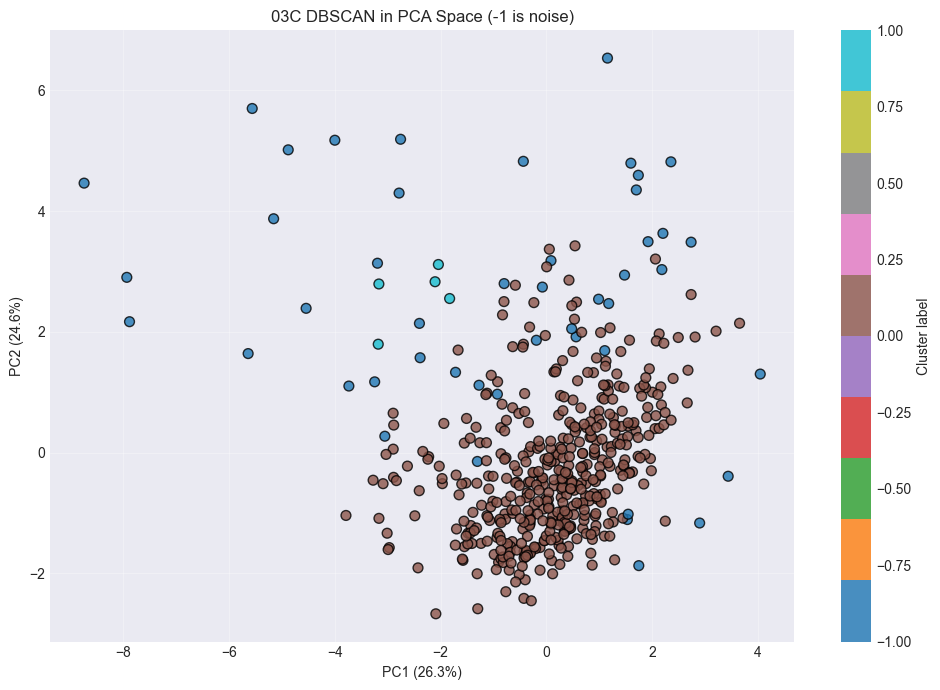

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_pca[:,0], X_pca[:,1], c=clustering_data['cluster'], cmap='tab10', s=50, edgecolor='black', alpha=0.8)
ax.set_title('03C DBSCAN in PCA Space (-1 is noise)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})'); ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.grid(alpha=0.3); plt.colorbar(sc, label='Cluster label')
plt.tight_layout(); plt.savefig(GRAPH_DIR / '03C_02_pca_scatter.png', dpi=300, bbox_inches='tight'); plt.show()

## Evaluation and Financial Interpretation
Use this section to assess statistical quality and practical finance meaning of clusters.

- Statistical checks: cluster concentration, feature differentiation profile.
- Finance checks: return-risk tradeoff, momentum dispersion, and liquidity context.
- Portfolio use: identify aggressive, defensive, and balanced baskets by regime.

=== Cluster Composition (including noise = -1) ===


,count,weight_pct
cluster,,
-1,47,9.31
0,453,89.70
1,5,0.99


Noise proportion: 9.31%
=== Core Cluster Feature Profile (noise excluded) ===


,volatility,avg_return,avg_volume,volume_volatility,momentum,price_range,trend_strength,price_level,volume_to_price_ratio
cluster,,,,,,,,,
0,0.0171,-0.0017,3.559953e+06,0.3895,-0.0344,0.0291,0.2600,0.9745,79333.6069
1,0.0186,-0.0002,3.087739e+07,0.3605,-0.0067,0.0245,0.2903,0.4840,779443.4797


=== Core Risk-Return Lens ===


,avg_return,volatility,momentum,price_range,return_to_risk
cluster,,,,,
0,-0.0017,0.0171,-0.0344,0.0291,-0.0984
1,-0.0002,0.0186,-0.0067,0.0245,-0.0098


[Insight] Core cluster 1 has the strongest return-to-risk proxy.
[Insight] Core cluster 0 is the most defensive regime by realized volatility.


C:\Users\25012923g\AppData\Local\Temp\ipykernel_20308\450169233.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=core_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')


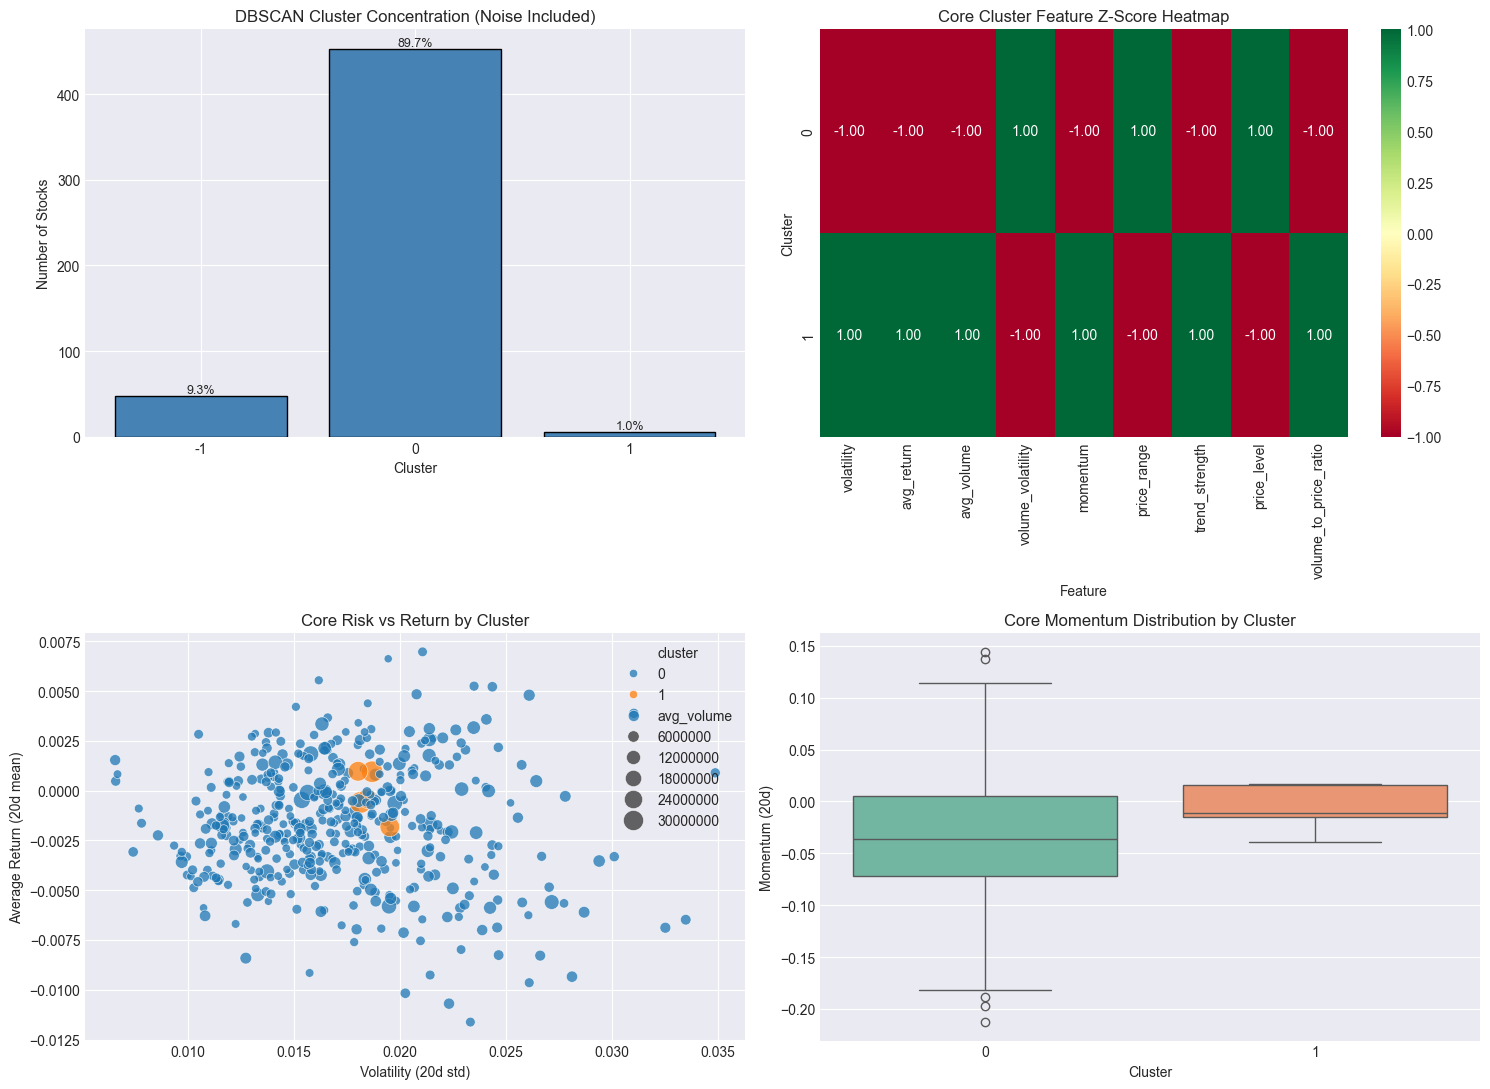

Saved evaluation dashboard: \\compdrive\Student5\25012923g\COMProfile\Documents\GitHub\ML-in-Finance-Data-Project\project_folder\03_stock_clustering_analysis\graph\03C_03_evaluation_dashboard.png


In [18]:
method_tag = '03C'
cluster_col = 'cluster'
eval_df = clustering_data.copy()

size_tbl = eval_df[cluster_col].value_counts().sort_index().rename('count').to_frame()
size_tbl['weight_pct'] = 100 * size_tbl['count'] / size_tbl['count'].sum()
noise_weight = float(size_tbl.loc[-1, 'weight_pct']) if -1 in size_tbl.index else 0.0

core_df = eval_df[eval_df[cluster_col] != -1].copy() if -1 in eval_df[cluster_col].unique() else eval_df.copy()

if core_df[cluster_col].nunique() >= 1:
    profile_mean = core_df.groupby(cluster_col)[feature_cols].mean()
else:
    profile_mean = pd.DataFrame(columns=feature_cols)

if not profile_mean.empty:
    profile_std = profile_mean.std(ddof=0).replace(0, np.nan)
    profile_z = ((profile_mean - profile_mean.mean()) / profile_std).fillna(0.0)
else:
    profile_z = pd.DataFrame()

risk_cols = ['avg_return', 'volatility', 'momentum', 'price_range']
risk_view = profile_mean[risk_cols].copy() if not profile_mean.empty else pd.DataFrame(columns=risk_cols)
if not risk_view.empty:
    risk_view['return_to_risk'] = risk_view['avg_return'] / risk_view['volatility'].replace(0, np.nan)

print('=== Cluster Composition (including noise = -1) ===')
display(size_tbl.round(2))
print(f'Noise proportion: {noise_weight:.2f}%')

if not profile_mean.empty:
    print('=== Core Cluster Feature Profile (noise excluded) ===')
    display(profile_mean.round(4))

if not risk_view.empty:
    print('=== Core Risk-Return Lens ===')
    display(risk_view.round(4))
    if len(risk_view) >= 2:
        best_rr = risk_view['return_to_risk'].idxmax()
        defensive = risk_view['volatility'].idxmin()
        print(f'[Insight] Core cluster {best_rr} has the strongest return-to-risk proxy.')
        print(f'[Insight] Core cluster {defensive} is the most defensive regime by realized volatility.')

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

bars = axes[0, 0].bar(size_tbl.index.astype(str), size_tbl['count'], color='steelblue', edgecolor='black')
axes[0, 0].set_title('DBSCAN Cluster Concentration (Noise Included)')
axes[0, 0].set_xlabel('Cluster'); axes[0, 0].set_ylabel('Number of Stocks')
for i, b in enumerate(bars):
    pct = size_tbl['weight_pct'].iloc[i]
    axes[0, 0].text(b.get_x() + b.get_width()/2, b.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

if not profile_z.empty:
    sns.heatmap(profile_z, cmap='RdYlGn', center=0, annot=True, fmt='.2f', ax=axes[0, 1])
    axes[0, 1].set_title('Core Cluster Feature Z-Score Heatmap')
    axes[0, 1].set_xlabel('Feature'); axes[0, 1].set_ylabel('Cluster')
else:
    axes[0, 1].axis('off')
    axes[0, 1].text(0.5, 0.5, 'No core clusters for heatmap', ha='center', va='center')

if not core_df.empty and core_df[cluster_col].nunique() >= 1:
    sns.scatterplot(data=core_df, x='volatility', y='avg_return', hue=cluster_col, size='avg_volume', sizes=(35, 240),
                    alpha=0.75, palette='tab10', ax=axes[1, 0])
    axes[1, 0].set_title('Core Risk vs Return by Cluster')
    axes[1, 0].set_xlabel('Volatility (20d std)'); axes[1, 0].set_ylabel('Average Return (20d mean)')
else:
    axes[1, 0].axis('off')
    axes[1, 0].text(0.5, 0.5, 'No core clusters for scatter', ha='center', va='center')

if not core_df.empty and core_df[cluster_col].nunique() >= 1:
    sns.boxplot(data=core_df, x=cluster_col, y='momentum', ax=axes[1, 1], palette='Set2')
    axes[1, 1].set_title('Core Momentum Distribution by Cluster')
    axes[1, 1].set_xlabel('Cluster'); axes[1, 1].set_ylabel('Momentum (20d)')
else:
    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, 'No core clusters for boxplot', ha='center', va='center')

plt.tight_layout()
dashboard_path = GRAPH_DIR / f'{method_tag}_03_evaluation_dashboard.png'
plt.savefig(dashboard_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved evaluation dashboard: {dashboard_path}')